# Aube T1: full-flood rollout

Evaluation of the regular 40 m and multimesh 40-80-160 m source-node models. The checkpoint is selected from the minimum saved training loss.

In [1]:
from pathlib import Path
import math
import pickle
import re
import sys

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import torch
from matplotlib.colors import ListedColormap
from omegaconf import OmegaConf


def find_project_root():
    for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (path / "python").exists() and (path / "bin").exists():
            return path
    raise RuntimeError("Project root not found.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from modulus.launch.utils import load_checkpoint
from python.CustomMeshGraphNet import MeshGraphNetWithSourceNodes
from python.create_dgl_dataset import TelemacDatasetWithSourceNodes
from python.python_code.data_manip.extraction.telemac_file import TelemacFile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [11]:
# User parameters
CONFIG_DIR = PROJECT_ROOT / "bin/conf/research"

# Replace these two paths with the SLURM .out or train .log files.
METHOD_SPECS = [
    {
        "name": "Multimesh 40-80-160 m phase 1",
        "config": CONFIG_DIR / "config_Aube_T1_ghost_40m_useQ_multi_70steps_phase1.yaml",
        "loss_log": Path("/users/m24046/m24046mrcr/gnn_modulus_test/bin/train_push_source_nodes.sh-104662-gnn.err"),
        "color": "#0A1045",
    },
    {
        "name": "Multimesh 40-80-160 m phase 2",
        "config": CONFIG_DIR / "config_Aube_T1_ghost_40m_useQ_multi_70steps_phase2.yaml",
        "loss_log": Path("/users/m24046/m24046mrcr/gnn_modulus_test/bin/train_push_source_nodes.sh-104679-gnn.err"),
        "color": "#00C2D1",
    },
    
        {
        "name": "Multimesh 40-80-160 m push",
        "config": CONFIG_DIR / "config_Aube_T1_ghost_40m_useQ_multi_70steps_pushforward.yaml",
        "loss_log": Path("/users/m24046/m24046mrcr/gnn_modulus_test/bin/train_push_source_nodes.sh-104762-gnn.err"),
        "color": "#F9E900",
    },
    
    {
        "name": "Multimesh 40-80-160 m push phase 2",
        "config": CONFIG_DIR / "config_Aube_T1_ghost_40m_useQ_multi_70steps_pushforward_phase2.yaml",
        "loss_log": Path("/users/m24046/m24046mrcr/gnn_modulus_test/bin/train_push_source_nodes.sh-105292-gnn.err"),
        "color": "#F6AF65",
    },
]

EVENTS = [
    {
        "name": "Q30 fullbase",
        "regular_dynamic": "/work/m24046/m24046mrcr/Test_Aube_T1_regular/dataset_40m_ghost/regular_short/12_T1_V9_Topo3_KV5_Q100_0_27-96_interpolated.pkl",
        "hydro": "/work/m24046/m24046mrcr/Test_Aube_T1_regular/original_dataset/T1_Q100_V1.liq",
    },
]
PERSISTENCE_NAME = "Persistence"

PLOT_METHOD_NAMES = ["Multimesh 40-80-160 m phase 1","Multimesh 40-80-160 m phase 2","Multimesh 40-80-160 m push","Multimesh 40-80-160 m push phase 2",PERSISTENCE_NAME]
REGULAR_MESH_PATH = "/work/m24046/m24046mrcr/Test_Aube_T1_regular/dataset_40m/Aube_regular_T1_40m.slf"


DT_SECONDS = 7200.0
REQUESTED_MAX_HOURS = 58
THRESHOLD_M = 0.05
CHECKPOINT_EVERY = 10

QUAL_EVENT_NAME = "Q30 fullbase"
QUAL_HOURS = [2,10,20,30, 40,50]

In [12]:
LOSS_PATTERN = re.compile(r"epoch:\s*(\d+).*?loss:\s*([0-9.eE+-]+)")


def best_saved_checkpoint(log_path):
    matches = LOSS_PATTERN.findall(Path(log_path).read_text(errors="replace"))
    saved_losses = [
        (int(epoch), float(loss))
        for epoch, loss in matches
        if int(epoch) % CHECKPOINT_EVERY == 0
    ]
    return min(saved_losses, key=lambda item: item[1])


def load_method(spec):
    epoch, loss = best_saved_checkpoint(spec["loss_log"])
    method = dict(spec)
    method["cfg"] = OmegaConf.load(spec["config"])
    method["epoch"] = epoch
    method["loss"] = loss
    return method


METHODS = [load_method(spec) for spec in METHOD_SPECS]
METHOD_BY_NAME = {method["name"]: method for method in METHODS}

METHOD_BY_NAME[PERSISTENCE_NAME] = {
    "name": PERSISTENCE_NAME,
    "color": "0.35",
    "linestyle": "--",
}

for method in METHODS:
    print(f'{method["name"]}: epoch={method["epoch"]}, training loss={method["loss"]:.6e}')

Multimesh 40-80-160 m phase 1: epoch=1000, training loss=2.864000e-01
Multimesh 40-80-160 m phase 2: epoch=500, training loss=1.836000e-01
Multimesh 40-80-160 m push: epoch=470, training loss=1.844000e-01
Multimesh 40-80-160 m push phase 2: epoch=290, training loss=2.160000e-01


In [13]:
def dynamic_length(path):
    with open(path, "rb") as handle:
        return len(pickle.load(handle))


available_steps = min(dynamic_length(event["regular_dynamic"]) for event in EVENTS) - 1
requested_steps = int(REQUESTED_MAX_HOURS * 3600.0 // DT_SECONDS)
MAX_STEPS = min(available_steps, requested_steps)
HORIZONS_STEPS = list(range(1, MAX_STEPS + 1))
HOURS = np.asarray(HORIZONS_STEPS, dtype=float) * DT_SECONDS / 3600.0
SEQUENCE_LENGTH = MAX_STEPS + 1

print(f"events={len(EVENTS)} | steps=1..{MAX_STEPS} | hours={HOURS[0]:g}..{HOURS[-1]:g}")

events=1 | steps=1..29 | hours=2..58


In [14]:
def build_dataset(method, event, sequence_length):
    cfg = method["cfg"]
    return TelemacDatasetWithSourceNodes(
        name=f'eval_{event["name"]}',
        data_dir=str(cfg.data_dir),
        dynamic_data_files=[event["regular_dynamic"]],
        hydro_data_files=[event["hydro"]],
        inlet_node_lists=OmegaConf.to_container(cfg.inlet_node_lists),
        use_q_feature=bool(cfg.use_q_feature),
        split="test",
        ckpt_path=str(cfg.ckpt_path),
        normalize=True,
        sequence_length=sequence_length,
        overlap=0,
        dt_seconds=float(cfg.dt_seconds),
    )


def build_model(method, dataset):
    cfg = method["cfg"] 
    model = MeshGraphNetWithSourceNodes(
        input_dim_nodes_phys=dataset.base_graph.ndata["static"].shape[1] + dataset.physical_dynamic_dim,
        input_dim_nodes_src=len(dataset.source_feature_names),
        input_dim_edges=int(cfg.num_edge_features),
        output_dim=int(cfg.num_output_features),
        processor_size=int(cfg.mp_layers),
        hidden_dim_processor=cfg.hidden_dim,
        hidden_dim_node_encoder=cfg.hidden_dim,
        hidden_dim_edge_encoder=cfg.hidden_dim,
        hidden_dim_node_decoder=cfg.hidden_dim,
        do_concat_trick=bool(cfg.do_concat_trick),
        num_processor_checkpoint_segments=int(cfg.num_processor_checkpoint_segments),
    )
    load_checkpoint(str(cfg.ckpt_path), models=model, device=device, epoch=method["epoch"])
    model.to(device).eval()
    return model


def build_context(dataset):
    stats = dataset.node_stats
    return {
        "static_dim": dataset.base_graph.ndata["static"].shape[1],
        "physical_dynamic_dim": dataset.physical_dynamic_dim,
        "state_mean": torch.tensor([stats["h"].item(), stats["u"].item(), stats["v"].item()], device=device),
        "state_std": torch.tensor([stats["h_std"].item(), stats["u_std"].item(), stats["v_std"].item()], device=device),
        "delta_mean": torch.tensor([stats["delta_h"].item(), stats["delta_u"].item(), stats["delta_v"].item()], device=device),
        "delta_std": torch.tensor([stats["delta_h_std"].item(), stats["delta_u_std"].item(), stats["delta_v_std"].item()], device=device),
    }


def rollout_sequence(model, dataset, sequence_index=0):
    sequence = dataset[sequence_index]
    context = build_context(dataset)
    state = {
        "graph": sequence[0]["graph"].to(device),
        "x_phys": sequence[0]["x_phys"].to(device),
        "x_src": sequence[0]["x_src"].to(device),
    }
    predictions = []
    targets = []

    for next_step in sequence[1:]:
        with torch.no_grad():
            y_pred_n = model(
                graph=state["graph"],
                x_phys=state["x_phys"],
                x_src=state["x_src"],
                edge_features=state["graph"].edata["x"].to(device),
            )

        start = context["static_dim"]
        x_t = state["x_phys"][:, start:start + 3] * context["state_std"] + context["state_mean"]
        y_pred = y_pred_n * context["delta_std"] + context["delta_mean"]
        x_pred = x_t + y_pred
        x_gt_n = next_step["x_phys"][:, start:start + 3].to(device)
        x_gt = x_gt_n * context["state_std"] + context["state_mean"]

        h_mask = (state["x_phys"][:, :4] == torch.tensor([0, 1, 0, 0], device=device)).all(dim=1)
        x_pred = x_pred.clone()
        x_pred[h_mask, 0] = x_gt[h_mask, 0]
        predictions.append(x_pred.cpu().numpy())
        targets.append(x_gt.cpu().numpy())

        x_next_n = (x_pred - context["state_mean"]) / (context["state_std"] + 1e-12)
        static = state["x_phys"][:, :start]
        forcing = next_step["x_phys"][:, start + 3:start + context["physical_dynamic_dim"]].to(device)
        state = {
            "graph": next_step["graph"].to(device),
            "x_phys": torch.cat((static, x_next_n, forcing), dim=1),
            "x_src": next_step["x_src"].to(device),
        }

    return np.stack(predictions), np.stack(targets)


def csi(prediction, target, threshold):
    pred_wet = prediction >= threshold
    target_wet = target >= threshold
    tp = np.logical_and(pred_wet, target_wet).sum()
    fp = np.logical_and(pred_wet, ~target_wet).sum()
    fn = np.logical_and(~pred_wet, target_wet).sum()
    return float(tp / (tp + fp + fn)) if tp + fp + fn else math.nan

In [15]:
def evaluate_method(method):
    first_dataset = build_dataset(method, EVENTS[0], SEQUENCE_LENGTH)
    model = build_model(method, first_dataset)
    event_payloads = {}

    for event in EVENTS:
        dataset = build_dataset(method, event, SEQUENCE_LENGTH)
        prediction, target = rollout_sequence(model, dataset)
        event_payloads[event["name"]] = {
            "prediction": prediction,
            "target": target,
            "l1": np.mean(np.abs(prediction - target), axis=1),
            "csi": np.asarray([
                csi(prediction[step, :, 0], target[step, :, 0], THRESHOLD_M)
                for step in range(MAX_STEPS)
            ]),
        }

    l1 = np.stack([payload["l1"] for payload in event_payloads.values()])
    csi_values = np.stack([payload["csi"] for payload in event_payloads.values()])
    return {
        "events": event_payloads,
        "l1_mean": np.nanmean(l1, axis=0),
        "l1_std": np.nanstd(l1, axis=0),
        "csi_mean": np.nanmean(csi_values, axis=0),
        "csi_std": np.nanstd(csi_values, axis=0),
    }

def persistence_sequence(dataset):
    sequence = dataset[0]
    context = build_context(dataset)
    start = context["static_dim"]
    mean = context["state_mean"].cpu().numpy()
    std = context["state_std"].cpu().numpy()

    states = np.stack([
        step["x_phys"][:, start:start + 3].cpu().numpy() * std + mean
        for step in sequence
    ])

    target = states[1:]
    prediction = np.repeat(states[[0]], len(target), axis=0)

    # Même hauteur imposée que celle fournie au modèle.
    onehot = sequence[0]["x_phys"][:, :4].cpu().numpy()
    h_mask = np.all(onehot == np.array([0, 1, 0, 0]), axis=1)
    prediction[:, h_mask, 0] = target[:, h_mask, 0]

    return prediction, target


def evaluate_persistence(reference_method):
    event_payloads = {}

    for event in EVENTS:
        dataset = build_dataset(reference_method, event, SEQUENCE_LENGTH)
        prediction, target = persistence_sequence(dataset)

        event_payloads[event["name"]] = {
            "prediction": prediction,
            "target": target,
            "l1": np.mean(np.abs(prediction - target), axis=1),
            "csi": np.asarray([
                csi(prediction[step, :, 0], target[step, :, 0], THRESHOLD_M)
                for step in range(MAX_STEPS)
            ]),
        }

    l1 = np.stack([payload["l1"] for payload in event_payloads.values()])
    csi_values = np.stack([payload["csi"] for payload in event_payloads.values()])

    return {
        "events": event_payloads,
        "l1_mean": np.nanmean(l1, axis=0),
        "l1_std": np.nanstd(l1, axis=0),
        "csi_mean": np.nanmean(csi_values, axis=0),
        "csi_std": np.nanstd(csi_values, axis=0),
    }

RESULTS = {method["name"]: evaluate_method(method) for method in METHODS}
RESULTS[PERSISTENCE_NAME] = evaluate_persistence(METHODS[0])

[21:22:21 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/Test_Aube_T1_regular/checkpoints/config_Aube_T1_ghost_40m_useQ_multi_70steps_phase1/Seed0/MeshGraphNet.0.1000.mdlus to device cuda
[21:22:21 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/Test_Aube_T1_regular/checkpoints/config_Aube_T1_ghost_40m_useQ_multi_70steps_phase1/Seed0/checkpoint.0.1000.pt to device cuda


Loading normalization statistics...
Loading normalization statistics...


[21:22:23 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/Test_Aube_T1_regular/checkpoints/config_Aube_T1_ghost_40m_useQ_multi_70steps_phase2/Seed0/MeshGraphNet.0.500.mdlus to device cuda
[21:22:23 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/Test_Aube_T1_regular/checkpoints/config_Aube_T1_ghost_40m_useQ_multi_70steps_phase2/Seed0/checkpoint.0.500.pt to device cuda


Loading normalization statistics...
Loading normalization statistics...


[21:22:24 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/Test_Aube_T1_regular/checkpoints/config_Aube_T1_ghost_40m_useQ_multi_70steps_pushforward/Seed0/MeshGraphNet.0.470.mdlus to device cuda
[21:22:24 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/Test_Aube_T1_regular/checkpoints/config_Aube_T1_ghost_40m_useQ_multi_70steps_pushforward/Seed0/checkpoint.0.470.pt to device cuda


Loading normalization statistics...
Loading normalization statistics...


[21:22:26 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/Test_Aube_T1_regular/checkpoints/config_Aube_T1_ghost_40m_useQ_multi_70steps_pushforward_phase2/Seed0/MeshGraphNet.0.290.mdlus to device cuda
[21:22:26 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/Test_Aube_T1_regular/checkpoints/config_Aube_T1_ghost_40m_useQ_multi_70steps_pushforward_phase2/Seed0/checkpoint.0.290.pt to device cuda


Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...


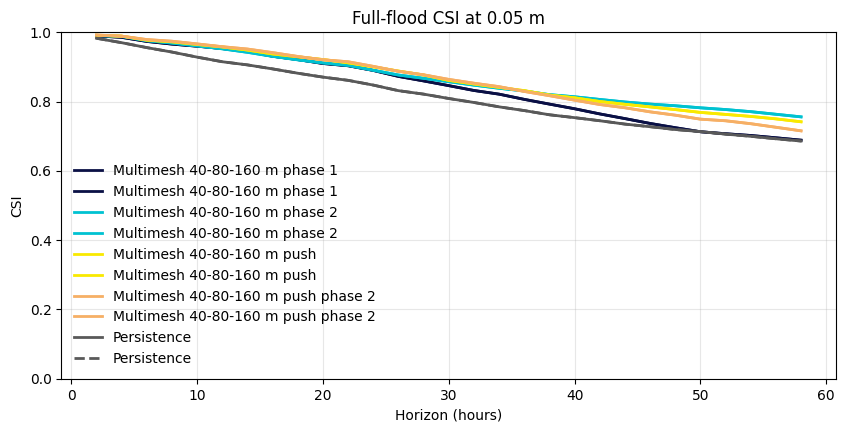

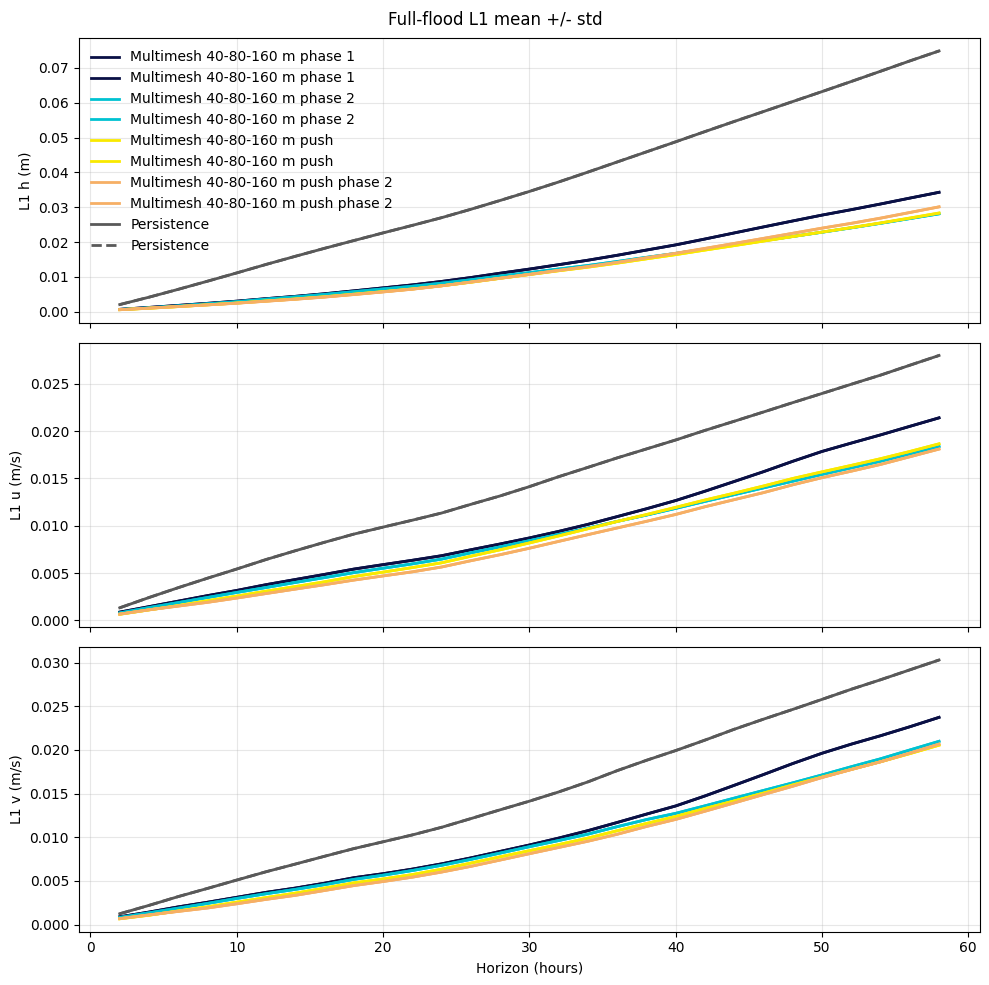

In [16]:
def plot_band(ax, mean, std, method, label):
    ax.plot(HOURS, mean, color=method["color"], linewidth=2, label=label)
    ax.fill_between(HOURS, mean - std, mean + std, color=method["color"], alpha=0.18)
    ax.plot(
    HOURS,
    mean,
    color=method["color"],
    linestyle=method.get("linestyle", "-"),
    linewidth=2,
    label=label,
)


fig, ax = plt.subplots(figsize=(10, 4.5))
for name in PLOT_METHOD_NAMES:
    plot_band(ax, RESULTS[name]["csi_mean"], RESULTS[name]["csi_std"], METHOD_BY_NAME[name], name)
ax.set(title=f"Full-flood CSI at {THRESHOLD_M:.2f} m", xlabel="Horizon (hours)", ylabel="CSI", ylim=(0, 1))
ax.grid(alpha=0.3)
ax.legend(frameon=False)
plt.show()

component_labels = ["L1 h (m)", "L1 u (m/s)", "L1 v (m/s)"]
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
for component, ax in enumerate(axes):
    for name in PLOT_METHOD_NAMES:
        plot_band(
            ax,
            RESULTS[name]["l1_mean"][:, component],
            RESULTS[name]["l1_std"][:, component],
            METHOD_BY_NAME[name],
            name,
        )
    ax.set_ylabel(component_labels[component])
    ax.grid(alpha=0.3)
axes[0].legend(frameon=False)
axes[-1].set_xlabel("Horizon (hours)")
fig.suptitle("Full-flood L1 mean +/- std")
fig.tight_layout()
plt.show()

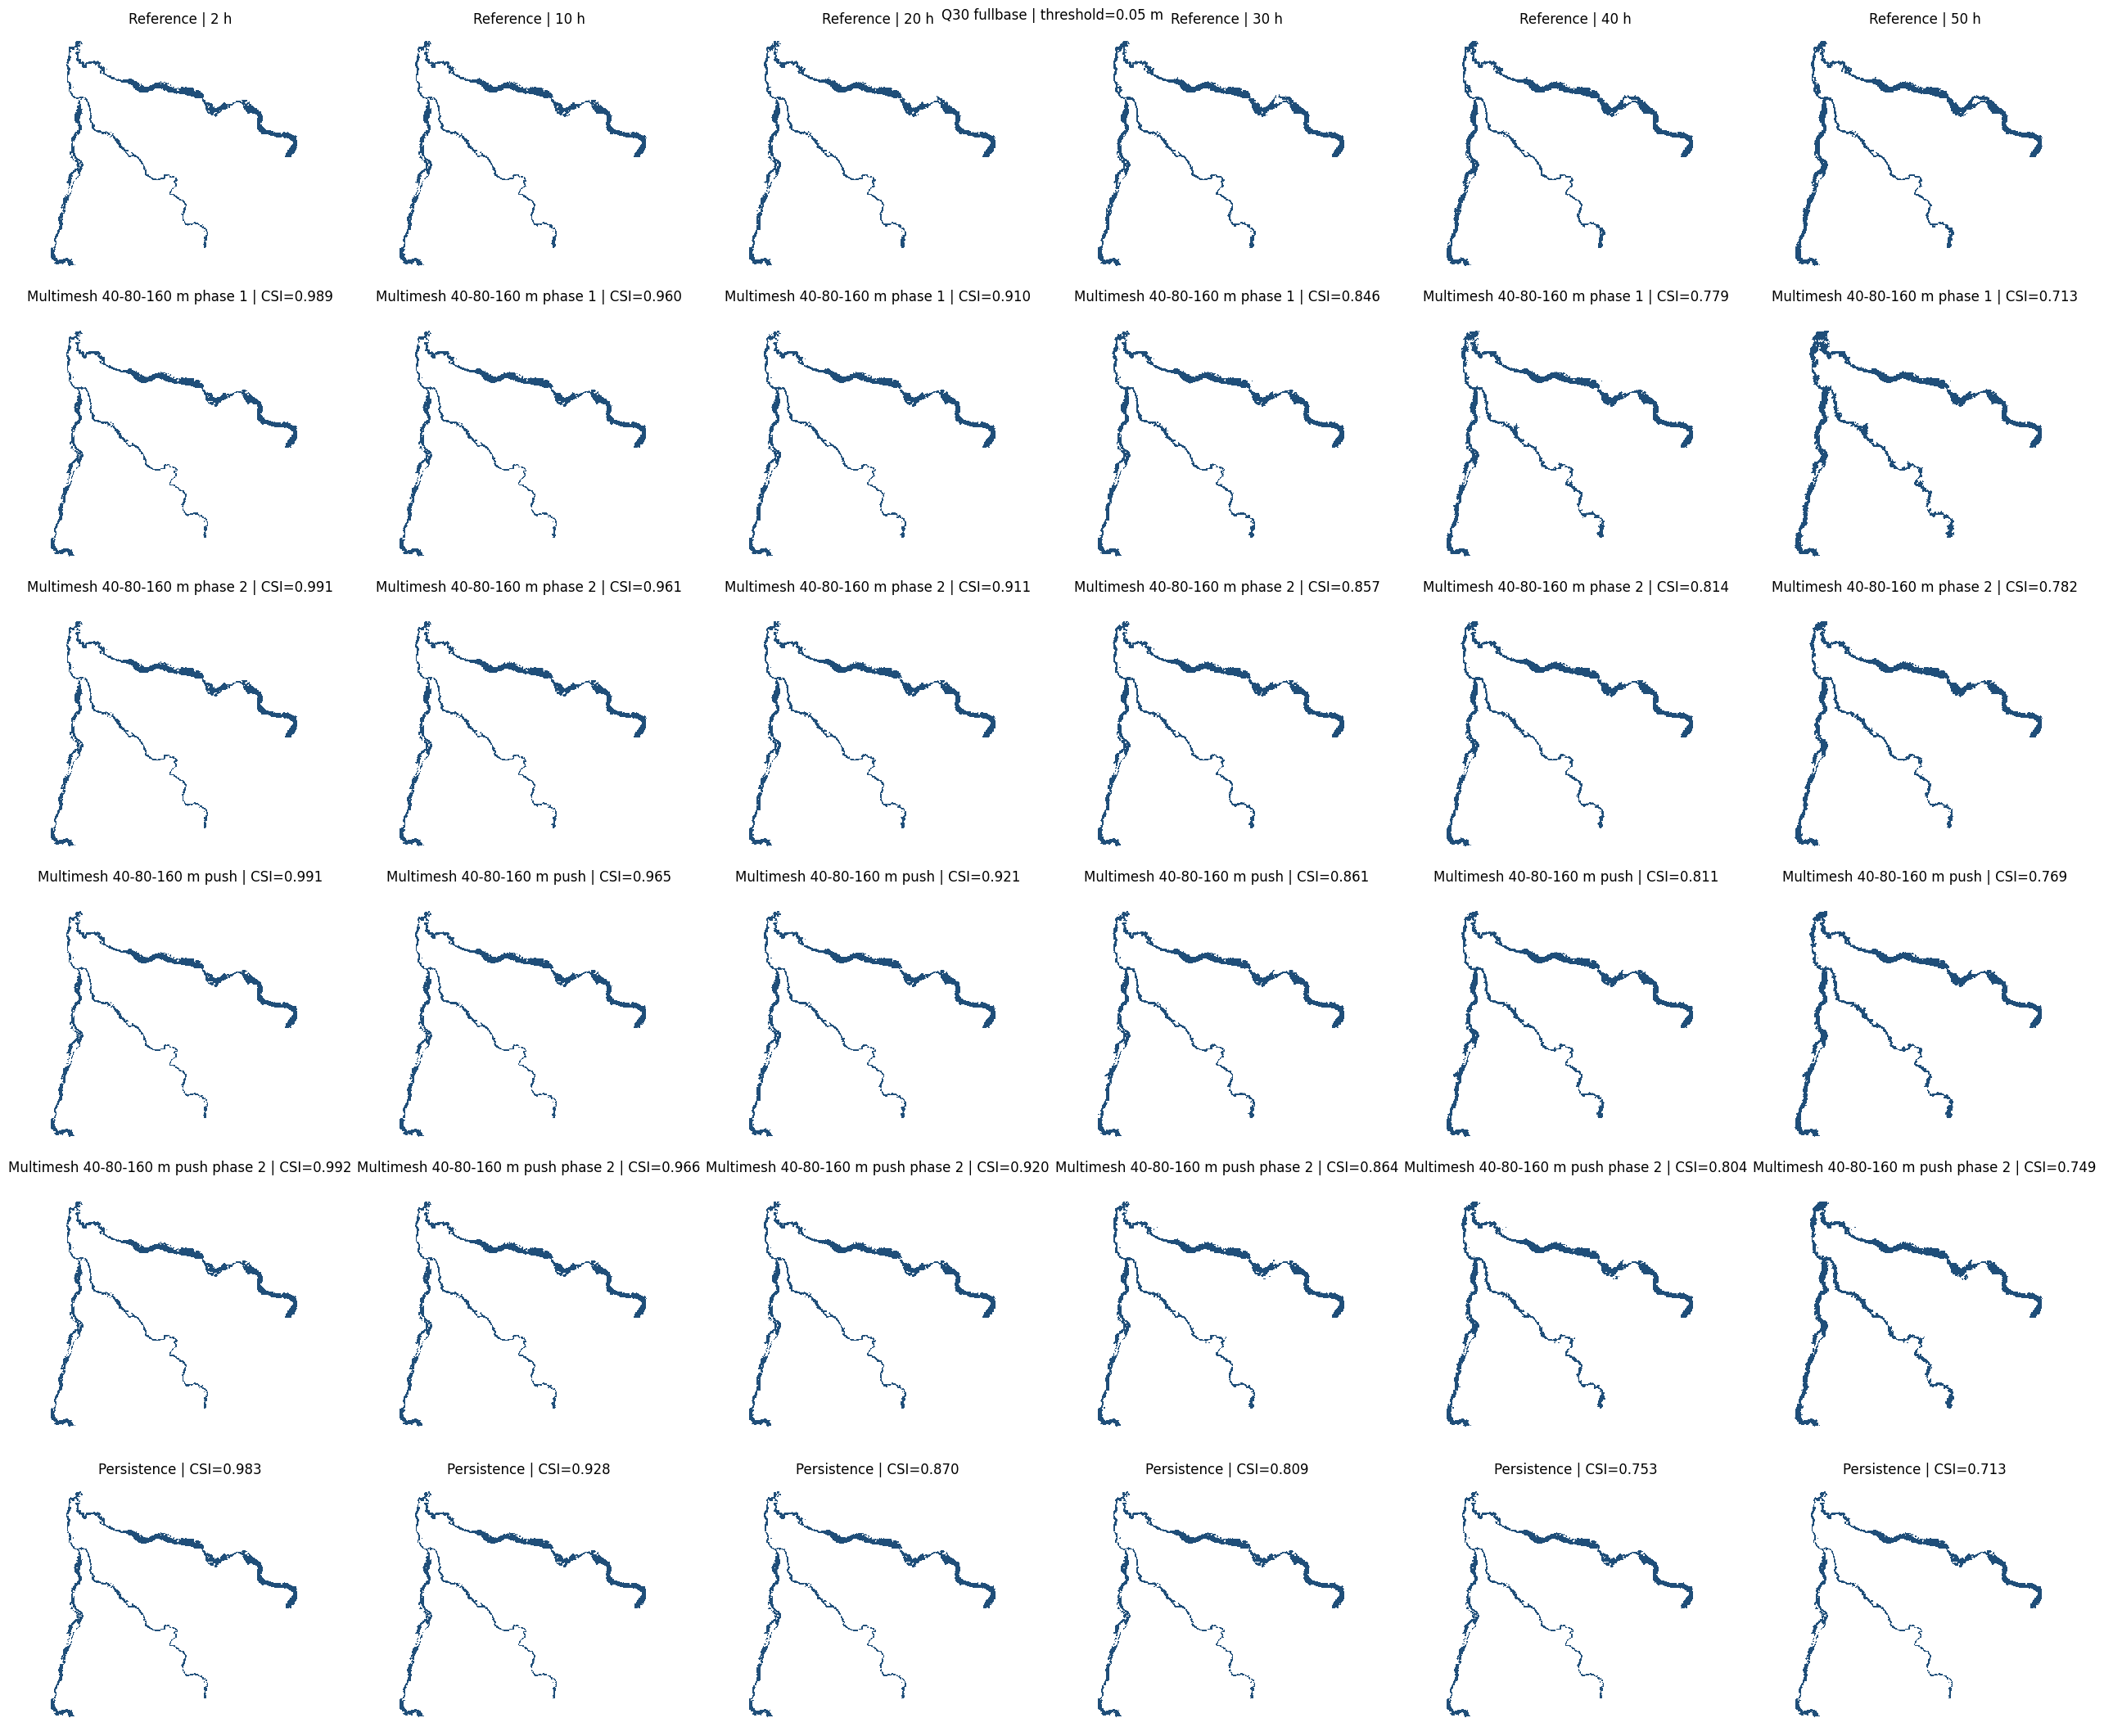

In [17]:
mesh = TelemacFile(REGULAR_MESH_PATH)
triangles = np.asarray(mesh.ikle2, dtype=np.int64)
triangles = triangles - triangles.min()
tri = mtri.Triangulation(np.asarray(mesh.meshx), np.asarray(mesh.meshy), triangles)
cmap = ListedColormap(["white", "#1f4e79"])


def node_to_face(values):
    return values[tri.triangles].max(axis=1).astype(float)


qual_steps = [int(hour * 3600.0 / DT_SECONDS) for hour in QUAL_HOURS]
fig, axes = plt.subplots(
    1 + len(PLOT_METHOD_NAMES),
    len(qual_steps),
    figsize=(4.3 * len(qual_steps), 3.6 * (1 + len(PLOT_METHOD_NAMES))),
    squeeze=False,
)

reference = RESULTS[PLOT_METHOD_NAMES[0]]["events"][QUAL_EVENT_NAME]["target"]
for column, step in enumerate(qual_steps):
    axes[0, column].tripcolor(
        tri,
        facecolors=node_to_face(reference[step - 1, :, 0] >= THRESHOLD_M),
        shading="flat",
        cmap=cmap,
        vmin=0,
        vmax=1,
    )
    axes[0, column].set_title(f"Reference | {step * DT_SECONDS / 3600:g} h")

    for row, name in enumerate(PLOT_METHOD_NAMES, start=1):
        payload = RESULTS[name]["events"][QUAL_EVENT_NAME]
        axes[row, column].tripcolor(
            tri,
            facecolors=node_to_face(payload["prediction"][step - 1, :, 0] >= THRESHOLD_M),
            shading="flat",
            cmap=cmap,
            vmin=0,
            vmax=1,
        )
        axes[row, column].set_title(f'{name} | CSI={payload["csi"][step - 1]:.3f}')

for ax in axes.flat:
    ax.set_aspect("equal")
    ax.set_axis_off()
fig.suptitle(f"{QUAL_EVENT_NAME} | threshold={THRESHOLD_M:.2f} m")
fig.tight_layout()
plt.show()

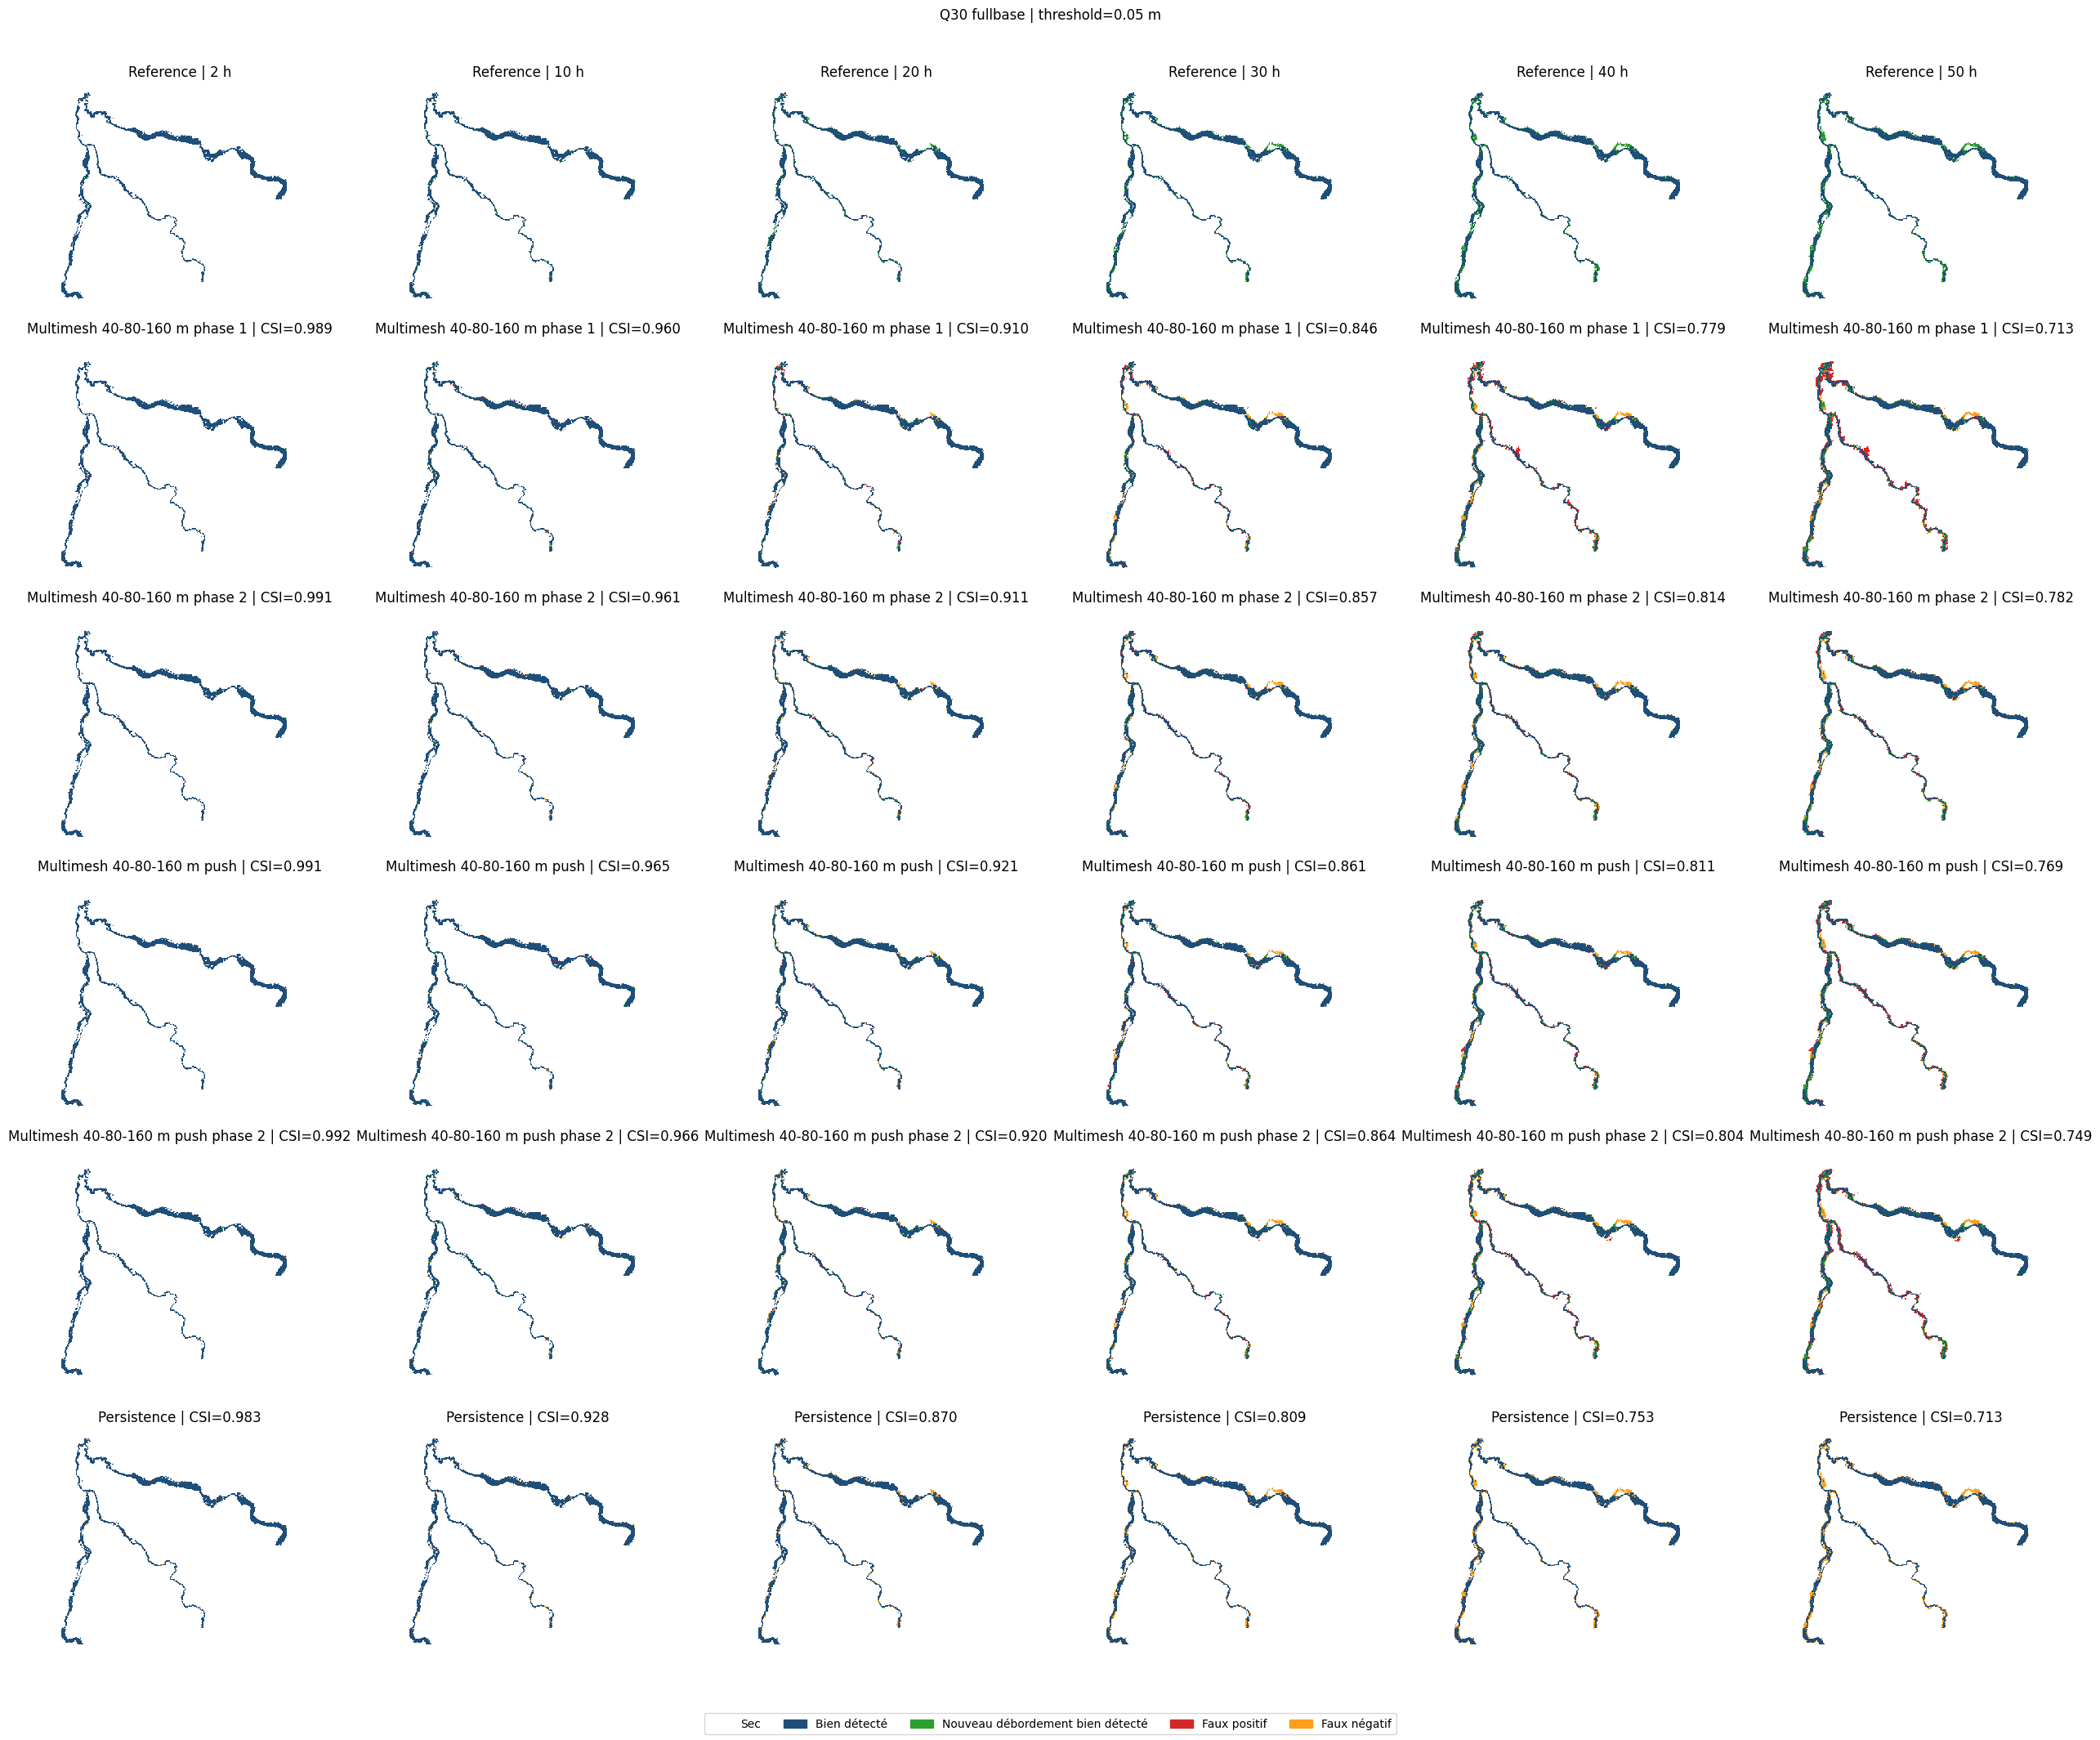

In [18]:
from matplotlib.patches import Patch

mesh = TelemacFile(REGULAR_MESH_PATH)
triangles = np.asarray(mesh.ikle2, dtype=np.int64)
triangles -= triangles.min()
tri = mtri.Triangulation(mesh.meshx, mesh.meshy, triangles)

cmap = ListedColormap([
    "white",      # 0 : sec
    "#1f4e79",    # 1 : vrai positif
    "#d62728",    # 2 : faux positif
    "#ff9f1c",    # 3 : faux négatif
    "#2ca02c",    # 4 : nouvelle inondation bien détectée
])


def node_to_face(values):
    return values[tri.triangles].max(axis=1).astype(bool)


qual_steps = [int(hour * 3600 / DT_SECONDS) for hour in QUAL_HOURS]
reference = RESULTS[PLOT_METHOD_NAMES[0]]["events"][QUAL_EVENT_NAME]["target"]
persistence = RESULTS[PERSISTENCE_NAME]["events"][QUAL_EVENT_NAME]["prediction"]

fig, axes = plt.subplots(
    1 + len(PLOT_METHOD_NAMES),
    len(qual_steps),
    figsize=(4.3 * len(qual_steps), 3.6 * (1 + len(PLOT_METHOD_NAMES))),
    squeeze=False,
)

for column, step in enumerate(qual_steps):
    reference_wet = node_to_face(
        reference[step - 1, :, 0] >= THRESHOLD_M
    )
    persistence_wet = node_to_face(
        persistence[step - 1, :, 0] >= THRESHOLD_M
    )

    # Cellules réellement inondées qui ne l'étaient pas dans la persistance.
    newly_flooded = reference_wet & ~persistence_wet

    reference_classes = np.zeros(len(triangles), dtype=int)
    reference_classes[reference_wet] = 1
    reference_classes[newly_flooded] = 4

    axes[0, column].tripcolor(
        tri,
        facecolors=reference_classes,
        shading="flat",
        cmap=cmap,
        vmin=0,
        vmax=4,
    )
    axes[0, column].set_title(
        f"Reference | {step * DT_SECONDS / 3600:g} h"
    )

    for row, name in enumerate(PLOT_METHOD_NAMES, start=1):
        payload = RESULTS[name]["events"][QUAL_EVENT_NAME]
        prediction_wet = node_to_face(
            payload["prediction"][step - 1, :, 0] >= THRESHOLD_M
        )

        classes = np.zeros(len(triangles), dtype=int)
        classes[reference_wet & prediction_wet] = 1
        classes[~reference_wet & prediction_wet] = 2
        classes[reference_wet & ~prediction_wet] = 3

        newly_flooded_detected = newly_flooded & prediction_wet
        classes[newly_flooded_detected] = 4

        axes[row, column].tripcolor(
            tri,
            facecolors=classes,
            shading="flat",
            cmap=cmap,
            vmin=0,
            vmax=4,
        )
        axes[row, column].set_title(
            f'{name} | CSI={payload["csi"][step - 1]:.3f}'
        )

for ax in axes.flat:
    ax.set_aspect("equal")
    ax.set_axis_off()

legend = [
    Patch(color="white", label="Sec"),
    Patch(color="#1f4e79", label="Bien détecté"),
    Patch(color="#2ca02c", label="Nouveau débordement bien détecté"),
    Patch(color="#d62728", label="Faux positif"),
    Patch(color="#ff9f1c", label="Faux négatif"),
]

fig.legend(handles=legend, loc="lower center", ncol=5)
fig.suptitle(f"{QUAL_EVENT_NAME} | threshold={THRESHOLD_M:.2f} m")
fig.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()

In [19]:
import pandas as pd


def safe_ratio(numerator, denominator):
    return numerator / denominator if denominator > 0 else np.nan


def masked_mean(values, mask):
    return values[mask].mean() if mask.any() else np.nan


x = np.asarray(mesh.meshx)
y = np.asarray(mesh.meshy)

x0, x1, x2 = x[triangles[:, 0]], x[triangles[:, 1]], x[triangles[:, 2]]
y0, y1, y2 = y[triangles[:, 0]], y[triangles[:, 1]], y[triangles[:, 2]]

face_area = 0.5 * np.abs(
    (x1 - x0) * (y2 - y0)
    - (x2 - x0) * (y1 - y0)
)


def wet_faces(wet_nodes):
    return wet_nodes[triangles].max(axis=1)


reference = RESULTS[PLOT_METHOD_NAMES[0]]["events"][QUAL_EVENT_NAME]["target"]
persistence = RESULTS[PERSISTENCE_NAME]["events"][QUAL_EVENT_NAME]["prediction"]

rows = []

for hour in QUAL_HOURS:
    step = int(round(hour * 3600 / DT_SECONDS))
    index = step - 1

    reference_state = reference[index]
    reference_wet_nodes = reference_state[:, 0] >= THRESHOLD_M
    reference_wet_faces = wet_faces(reference_wet_nodes)

    persistence_wet_faces = wet_faces(
        persistence[index, :, 0] >= THRESHOLD_M
    )
    newly_flooded_faces = reference_wet_faces & ~persistence_wet_faces
    newly_flooded_area = face_area[newly_flooded_faces].sum()

    for name in PLOT_METHOD_NAMES:
        payload = RESULTS[name]["events"][QUAL_EVENT_NAME]
        prediction = payload["prediction"][index]
        difference_h = prediction[:, 0] - reference_state[:, 0]

        prediction_wet_nodes = prediction[:, 0] >= THRESHOLD_M
        prediction_wet_faces = wet_faces(prediction_wet_nodes)

        true_positive = reference_wet_faces & prediction_wet_faces
        false_positive = ~reference_wet_faces & prediction_wet_faces
        false_negative = reference_wet_faces & ~prediction_wet_faces

        tp_area = face_area[true_positive].sum()
        fp_area = face_area[false_positive].sum()
        fn_area = face_area[false_negative].sum()
        reference_area = face_area[reference_wet_faces].sum()
        prediction_area = face_area[prediction_wet_faces].sum()

        newly_detected_area = face_area[
            newly_flooded_faces & prediction_wet_faces
        ].sum()

        fp_nodes = ~reference_wet_nodes & prediction_wet_nodes
        fn_nodes = reference_wet_nodes & ~prediction_wet_nodes

        rows.append({
            "method": name,
            "hours": hour,
            "L1_h_m": payload["l1"][index, 0],
            "L1_u_mps": payload["l1"][index, 1],
            "L1_v_mps": payload["l1"][index, 2],
            "h_bias_cm": 100 * difference_h.mean(),
            "CSI_nodes": payload["csi"][index],
            "CSI_area": safe_ratio(tp_area, tp_area + fp_area + fn_area),
            "precision_area_%": 100 * safe_ratio(tp_area, tp_area + fp_area),
            "recall_area_%": 100 * safe_ratio(tp_area, tp_area + fn_area),
            "new_flood_recall_%": 100 * safe_ratio(
                newly_detected_area,
                newly_flooded_area,
            ),
            "wet_area_ratio": safe_ratio(prediction_area, reference_area),
            "FP_area_km2": fp_area / 1e6,
            "FN_area_km2": fn_area / 1e6,
            "FP_h_bias_cm": 100 * masked_mean(difference_h, fp_nodes),
            "FN_h_bias_cm": 100 * masked_mean(difference_h, fn_nodes),
        })

metrics = pd.DataFrame(rows)

physical_columns = [
    "method", "hours",
    "L1_h_m", "L1_u_mps", "L1_v_mps",
    "h_bias_cm", "CSI_nodes",
]

extent_columns = [
    "method", "hours",
    "CSI_area", "precision_area_%", "recall_area_%",
    "new_flood_recall_%", "wet_area_ratio",
    "FP_area_km2", "FN_area_km2",
    "FP_h_bias_cm", "FN_h_bias_cm",
]

display(metrics[physical_columns].round(4))
display(metrics[extent_columns].round(4))

,method,hours,L1_h_m,L1_u_mps,L1_v_mps,h_bias_cm,CSI_nodes
0,Multimesh 40-80-160 m phase 1,2,0.0007,0.0009,0.0009,0.0017,0.9894
1,Multimesh 40-80-160 m phase 2,2,0.0007,0.0008,0.0008,-0.0133,0.9906
2,Multimesh 40-80-160 m push,2,0.0006,0.0006,0.0007,-0.0010,0.9912
3,Multimesh 40-80-160 m push phase 2,2,0.0006,0.0007,0.0007,0.0018,0.9919
4,Persistence,2,0.0021,0.0013,0.0012,-0.2018,0.9826
5,Multimesh 40-80-160 m phase 1,10,0.0031,0.0032,0.0031,-0.0089,0.9597
6,Multimesh 40-80-160 m phase 2,10,0.0029,0.0029,0.0030,-0.0552,0.9605
7,Multimesh 40-80-160 m push,10,0.0025,0.0026,0.0026,-0.0112,0.9647
8,Multimesh 40-80-160 m push phase 2,10,0.0025,0.0024,0.0024,0.0054,0.9662
9,Persistence,10,0.0112,0.0054,0.0051,-1.1131,0.9281


,method,hours,CSI_area,precision_area_%,recall_area_%,new_flood_recall_%,wet_area_ratio,FP_area_km2,FN_area_km2,FP_h_bias_cm,FN_h_bias_cm
0,Multimesh 40-80-160 m phase 1,2,0.9936,99.8047,99.5557,57.3099,0.9975,0.0256,0.0584,0.4559,-2.9746
1,Multimesh 40-80-160 m phase 2,2,0.9939,99.8352,99.5557,59.0643,0.9972,0.0216,0.0584,0.3793,-2.6703
2,Multimesh 40-80-160 m push,2,0.9948,99.8353,99.6409,65.4971,0.9981,0.0216,0.0472,0.3417,-2.2147
3,Multimesh 40-80-160 m push phase 2,2,0.9948,99.8111,99.6713,68.4211,0.9986,0.0248,0.0432,0.3420,-2.5340
4,Persistence,2,0.9895,99.9938,98.9592,0.0000,0.9897,0.0008,0.1368,0.6176,-2.8364
5,Multimesh 40-80-160 m phase 1,10,0.9686,98.9864,97.8266,54.5900,0.9883,0.1368,0.2968,2.5182,-6.7517
6,Multimesh 40-80-160 m phase 2,10,0.9696,98.9643,97.9555,57.2827,0.9898,0.1400,0.2792,3.2080,-6.9868
7,Multimesh 40-80-160 m push,10,0.9735,99.1771,98.1429,61.1995,0.9896,0.1112,0.2536,2.6735,-6.6337
8,Multimesh 40-80-160 m push phase 2,10,0.9748,99.2481,98.2015,62.4235,0.9895,0.1016,0.2456,1.9142,-6.4745
9,Persistence,10,0.9517,99.9569,95.2138,0.0000,0.9525,0.0056,0.6536,0.7052,-7.4504
